### Importation of Libraries

Imports essential Python libraries for data handling (pandas, numpy), visualization (matplotlib, seaborn), machine learning (scikit-learn), and model persistence (joblib).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

### Generation of Synthetic Data

This code block generates a synthetic dataset using NumPy and pandas to simulate real-world demographic and health-related data. The line np.random.seed(42) ensures that the random numbers generated are reproducible each time the code runs. The variable n_samples = 100 specifies that the dataset will contain 100 observations (rows). A pandas DataFrame named df is then created, containing several columns that represent potential predictors of HIV prevalence. Each column is filled with random values drawn from a uniform distribution within a specified range — for example, population density values range between 300 and 1200 persons per km², median age ranges between 18 and 35 years, and poverty rate between 20% and 70%. The resulting dataset provides a controlled, simulated environment for testing and demonstrating data analysis and modeling techniques.

In [28]:
np.random.seed(42)
n_samples = 100

df = pd.DataFrame({
    'population_density': np.random.uniform(300, 1200, n_samples),  # persons per km²
    'median_age': np.random.uniform(18, 35, n_samples),
    'female_education_years': np.random.uniform(4, 12, n_samples),
    'male_education_years': np.random.uniform(4, 12, n_samples),
    'poverty_rate': np.random.uniform(20, 70, n_samples),
    'male_circumcision_rate': np.random.uniform(40, 95, n_samples),
    'condom_use_rate': np.random.uniform(30, 80, n_samples),
    'testing_rate': np.random.uniform(30, 90, n_samples),
    'health_facilities_per_10k': np.random.uniform(0.5, 4.0, n_samples)
})



### Simulation of Target – HIV Prevalence with Plausible Relationships

This code block creates a synthetic target variable called hiv_prevalence based on a linear combination of several predictors in the dataset. The formula assigns weights to variables that are known to influence HIV prevalence: higher male circumcision and condom use rates are associated with lower prevalence (negative coefficients), while higher poverty rates tend to increase prevalence (positive coefficient). Additionally, more female education years are linked to lower HIV prevalence, reflecting the protective role of education. Random noise (np.random.normal(0, 1.5, n_samples)) is added to simulate natural variation in real-world data.

The next line, clip(lower=5, upper=35), ensures that HIV prevalence values remain within a realistic percentage range (5%–35%). Finally, the last three lines display the first few rows of the dataset (df.head()), summary statistics (df.describe()), and missing value counts (df.isnull().sum()), allowing for quick inspection of the data’s structure and quality.

In [29]:
df['hiv_prevalence'] = (
    30
    - 0.1 * df['male_circumcision_rate']
    - 0.05 * df['condom_use_rate']
    + 0.12 * df['poverty_rate']
    - 0.2 * df['female_education_years']
    + np.random.normal(0, 1.5, n_samples)
)

# Clip values to reasonable % range
df['hiv_prevalence'] = df['hiv_prevalence'].clip(lower=5, upper=35)

#  Inspect data
print(df.head())
print(df.describe())
print(df.isnull().sum())

   population_density  median_age  female_education_years  \
0          637.086107   18.534296                9.136253   
1         1155.642876   28.818977                4.673120   
2          958.794548   23.344052                5.293030   
3          838.792636   26.645702               11.188434   
4          440.416776   33.428630                8.851432   

   male_education_years  poverty_rate  male_circumcision_rate  \
0              4.413454     25.156193               78.398894   
1              8.250837     65.127645               69.485300   
2              8.325081     45.262619               57.024019   
3              9.099439     61.322873               84.758726   
4              9.808731     36.002480               77.660214   

   condom_use_rate  testing_rate  health_facilities_per_10k  hiv_prevalence  
0        38.446753     61.955366                   2.975335       21.918465  
1        43.929517     33.109412                   1.033887       25.859017  
2       

### Exploratory Data Ananlysis

This section performs exploratory data analysis (EDA) to visualize the structure and relationships in the dataset.

The first plot creates a histogram of the hiv_prevalence variable using Seaborn’s histplot(). The bins=10 parameter divides the data into ten intervals, while kde=True overlays a smooth kernel density estimate (KDE) curve that shows the distribution’s shape. The figure size and axis labels make the visualization clear and readable. This helps assess how HIV prevalence values are spread across the population — whether the distribution is skewed, uniform, or roughly normal.

The second plot uses sns.heatmap(df.corr(), annot=True, cmap='coolwarm') to generate a correlation matrix, showing how strongly each variable is related to others. The color map (coolwarm) visually distinguishes positive and negative correlations, while annot=True prints correlation coefficients inside the cells. This visualization is useful for identifying which factors (e.g., poverty rate or education level) most strongly influence HIV prevalence in the dataset.

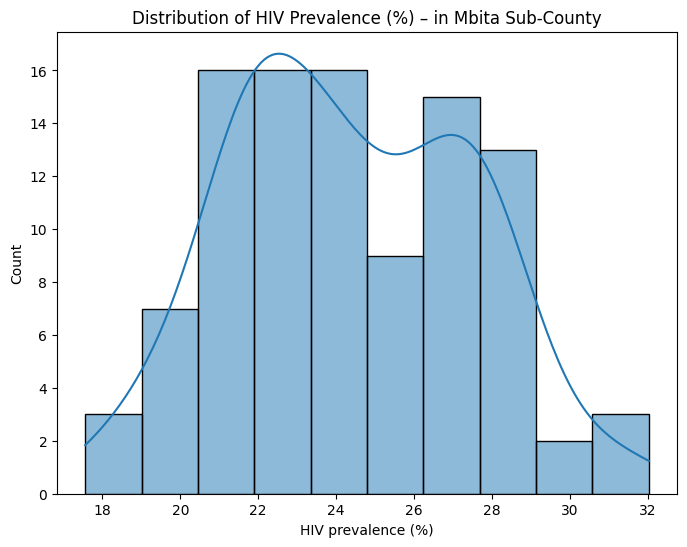

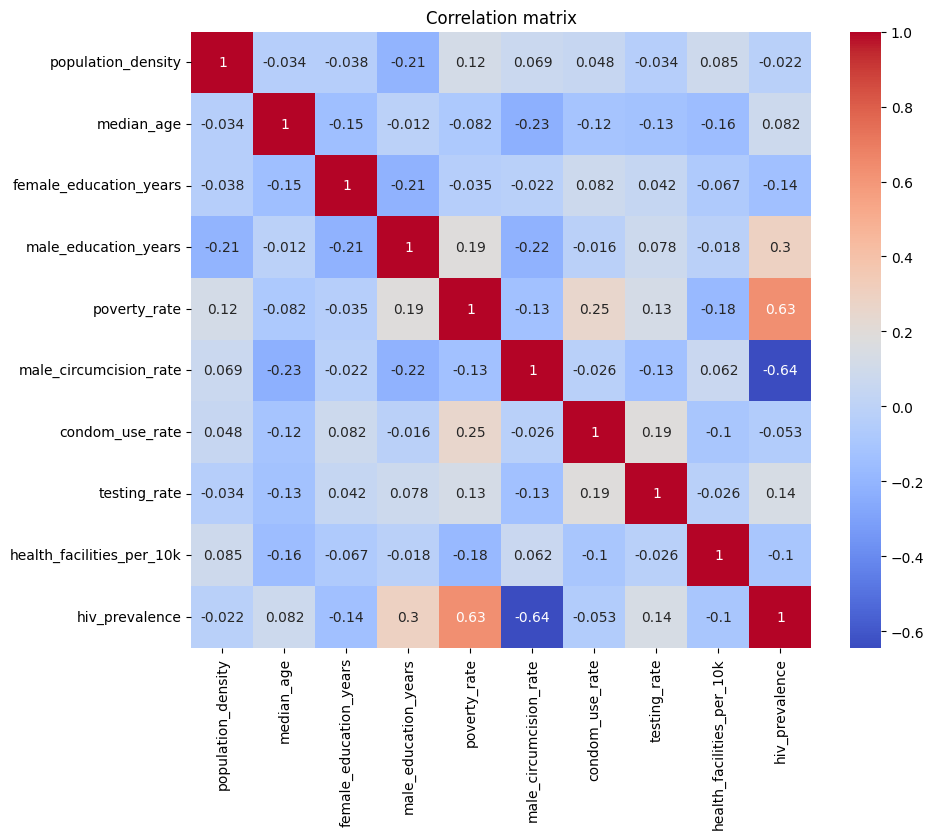

In [30]:
plt.figure(figsize=(8,6))
sns.histplot(df['hiv_prevalence'], bins=10, kde=True)
plt.title("Distribution of HIV Prevalence (%) – in Mbita Sub-County")
plt.xlabel("HIV prevalence (%)")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

### Data Preprocessing

This section prepares the dataset for machine learning by separating features, splitting data, and standardizing values.

First, the independent variables (predictors) are stored in X by dropping the target column 'hiv_prevalence', while the dependent variable (target) is stored in y. The dataset is then split into training and testing sets using train_test_split(), where test_size=0.2 allocates 20% of the data for testing and 80% for training. Setting random_state=42 ensures that the split is reproducible each time the code runs.

Next, a StandardScaler is used to standardize the feature values. This process rescales each feature so that it has a mean of 0 and a standard deviation of 1. The scaler is first fitted to the training data (fit_transform) and then applied to the test data (transform) to prevent data leakage. Standardization ensures that all features contribute equally to the model and improves the performance and stability of algorithms such as Random Forests and other machine learning models.

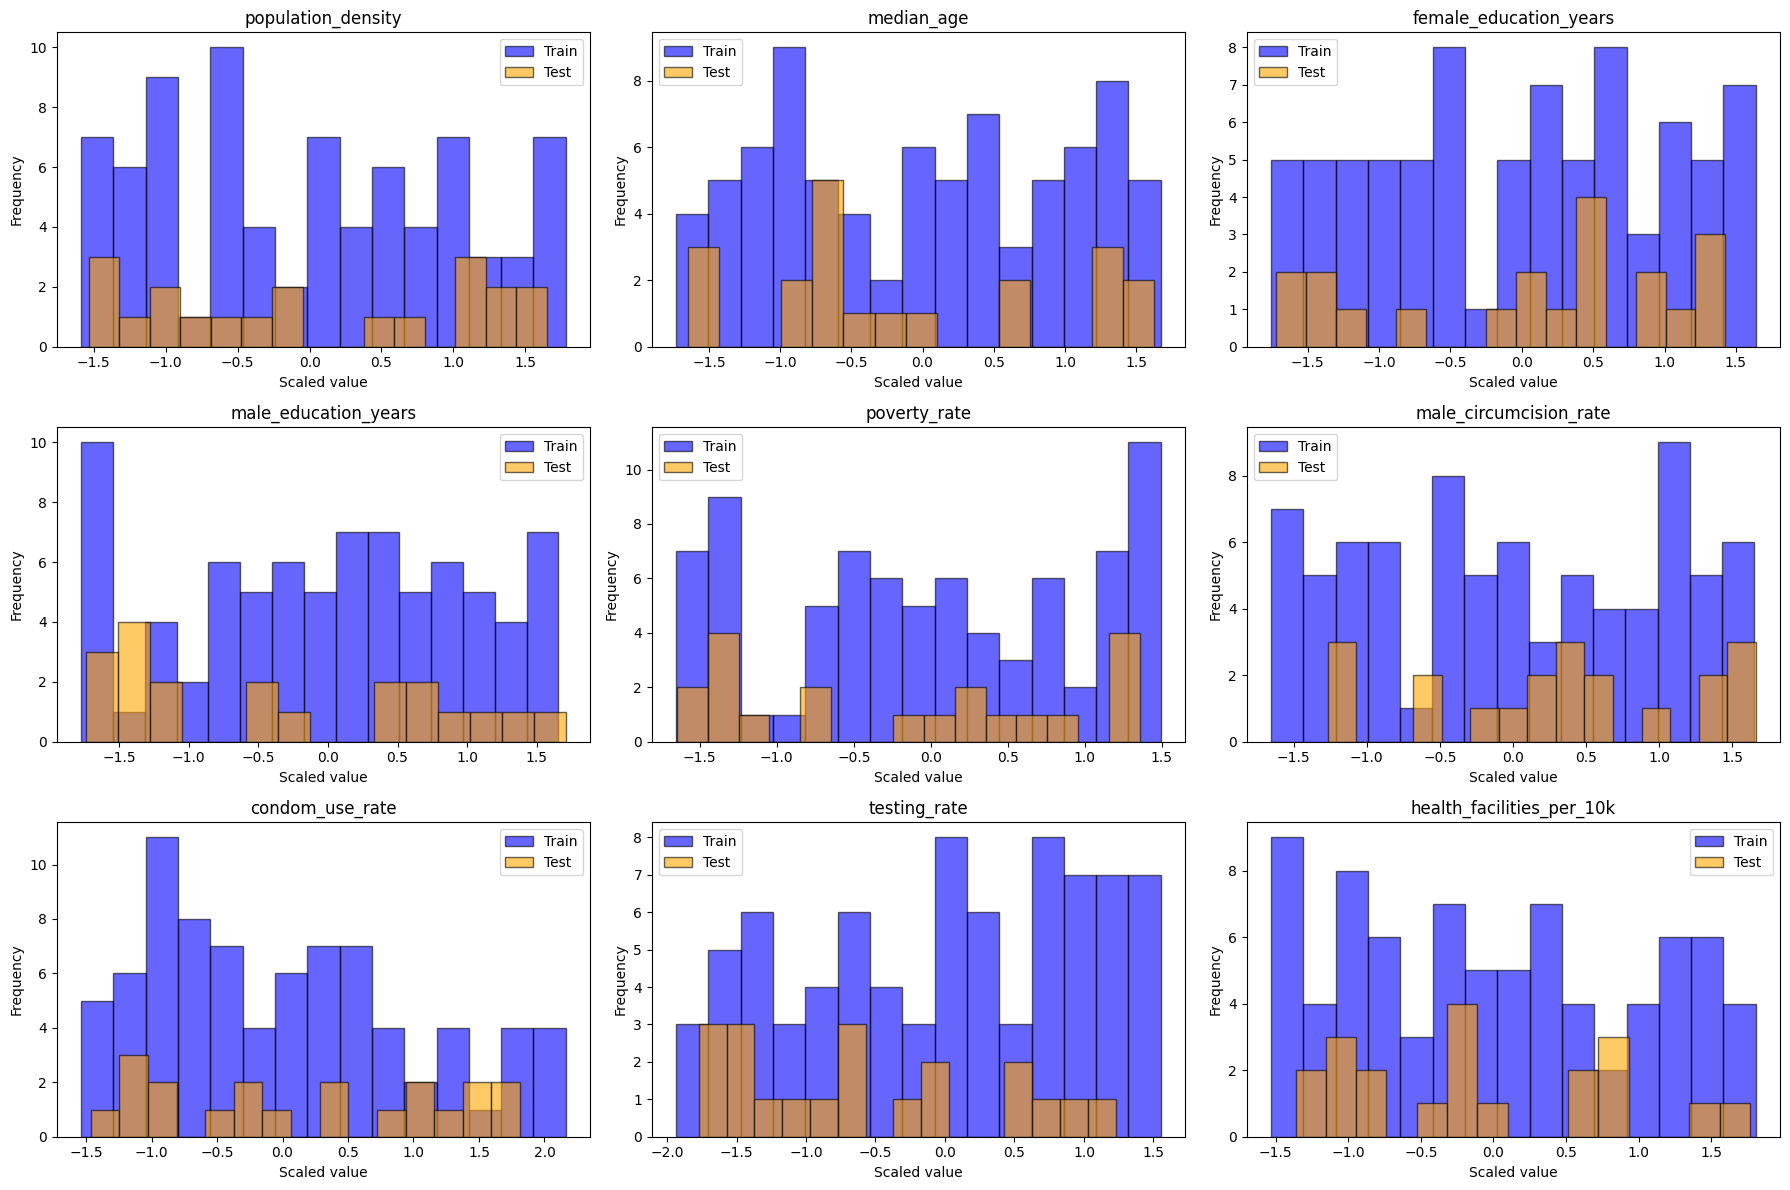

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('hiv_prevalence', axis=1)
y = df['hiv_prevalence']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays to DataFrames for plotting
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Plot distributions of each feature in training and test sets
plt.figure(figsize=(18, 12))

for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i+1)  # 3x3 grid for 9 features
    plt.hist(X_train_scaled_df[col], bins=15, alpha=0.6, label='Train', color='blue', edgecolor='k')
    plt.hist(X_test_scaled_df[col], bins=15, alpha=0.6, label='Test', color='orange', edgecolor='k')
    plt.title(col)
    plt.xlabel('Scaled value')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()


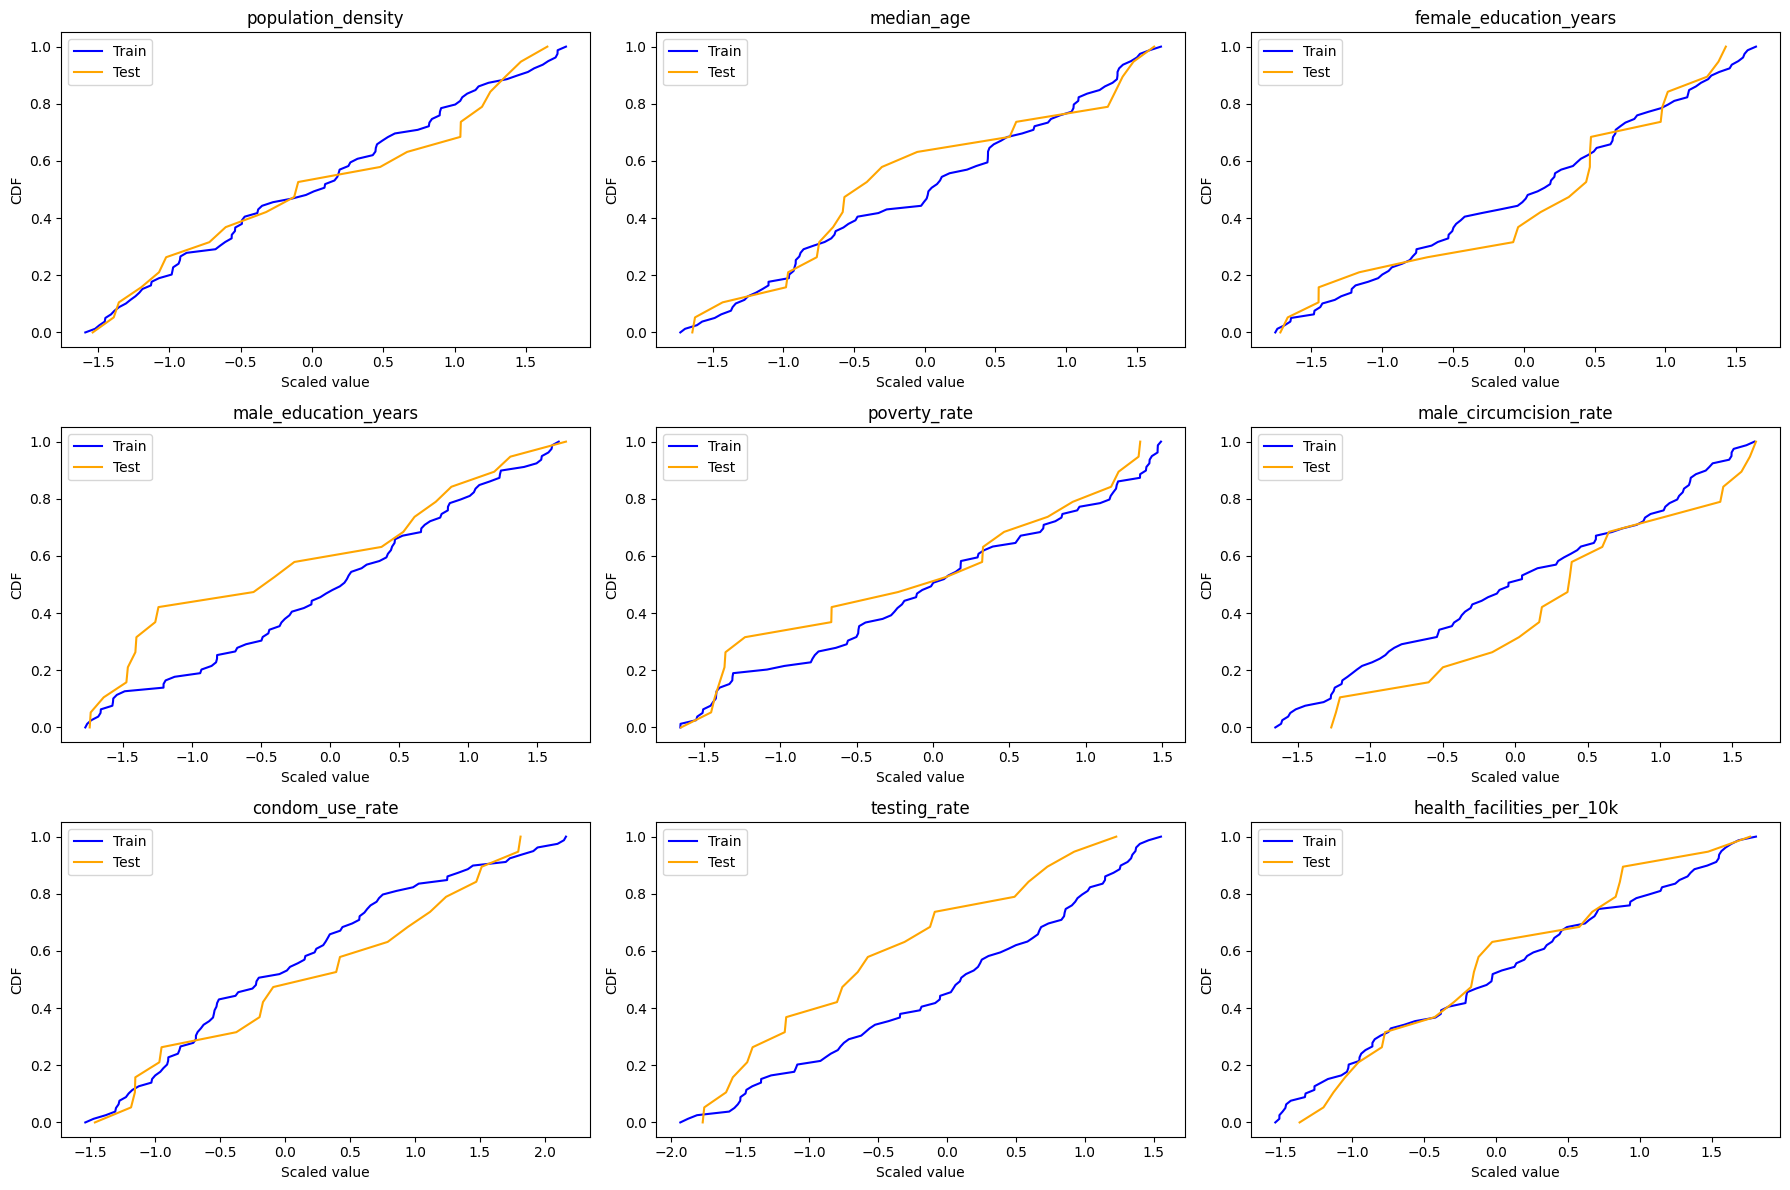

In [32]:
X = df.drop('hiv_prevalence', axis=1)
y = df['hiv_prevalence']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features and target
X = df.drop('hiv_prevalence', axis=1)
y = df['hiv_prevalence']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays to DataFrames for plotting
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Plot line graphs for each feature
plt.figure(figsize=(18, 12))

for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i+1)  # 3x3 grid for 9 features
    # Sort values for smoother lines
    train_sorted = np.sort(X_train_scaled_df[col].values)
    test_sorted = np.sort(X_test_scaled_df[col].values)
    plt.plot(train_sorted, np.linspace(0, 1, len(train_sorted)), label='Train', color='blue')
    plt.plot(test_sorted, np.linspace(0, 1, len(test_sorted)), label='Test', color='orange')
    plt.title(col)
    plt.xlabel('Scaled value')
    plt.ylabel('CDF')
    plt.legend()

plt.tight_layout()
plt.show()


This cell shows how many rows and columns are in your training and test sets, and prints sample values from the target variable.

In [33]:
# Display the shape and first few rows of the training and test sets
print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

print("\nTraining target sample:")
print(y_train.head())

print("\nTest target sample:")
print(y_test.head())


Training features shape: (80, 9)
Test features shape: (20, 9)

Training target sample:
55    23.599235
88    29.555704
26    21.732244
42    27.593898
69    27.726681
Name: hiv_prevalence, dtype: float64

Test target sample:
83    27.166244
53    23.972302
70    21.565090
45    24.182603
44    24.491645
Name: hiv_prevalence, dtype: float64


This visualizes how each feature in the training set looks after standardization (mean ≈ 0, standard deviation ≈ 1).

<Figure size 1200x800 with 0 Axes>

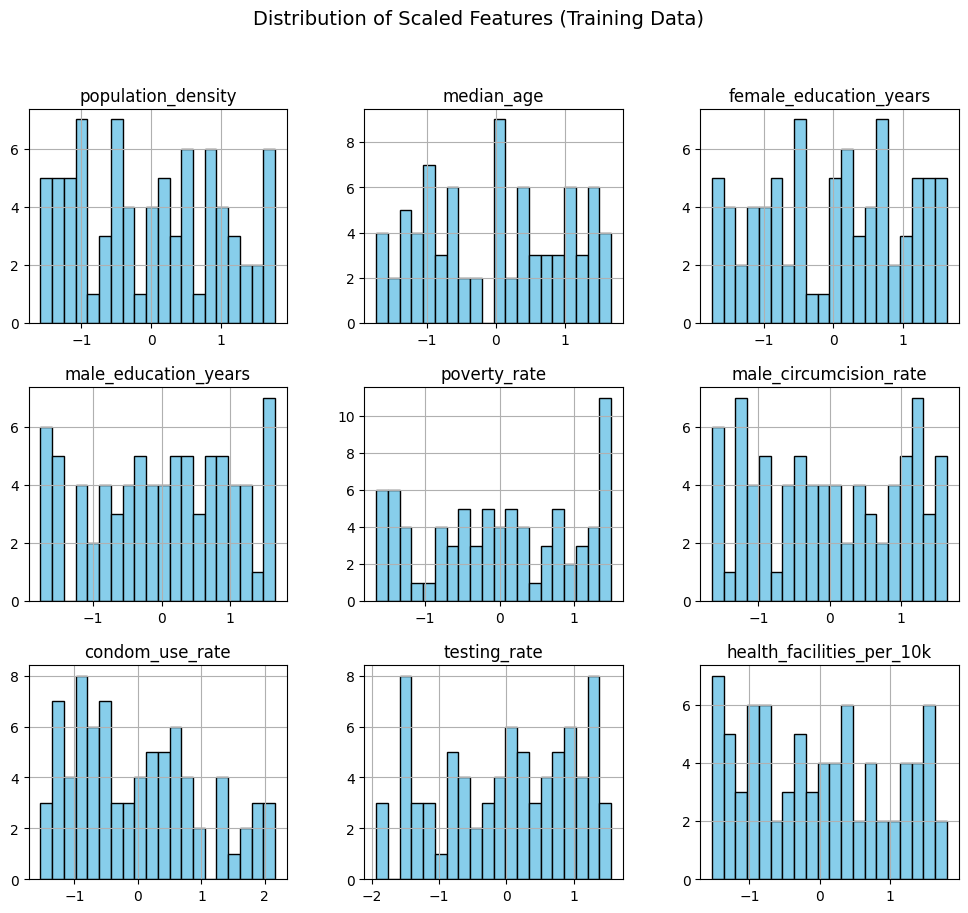

In [34]:
# Convert scaled arrays back to DataFrame for plotting
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Plot histograms to compare feature distributions
plt.figure(figsize=(12, 8))
X_train_scaled_df.hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Scaled Features (Training Data)", fontsize=14)
plt.show()


Checks that the training and test sets have similar statistical properties after scaling — confirming consistent preprocessing.

In [35]:
# Compare the mean and standard deviation of scaled training vs test sets
train_stats = X_train_scaled_df.describe().loc[['mean', 'std']]
test_stats = X_test_scaled_df.describe().loc[['mean', 'std']]

comparison = pd.concat([train_stats, test_stats], keys=['Train', 'Test'])
print(comparison)


            population_density    median_age  female_education_years  \
Train mean       -1.554312e-16 -2.789435e-16            6.938894e-16   
      std         1.006309e+00  1.006309e+00            1.006309e+00   
Test  mean        3.574762e-02 -1.160848e-01            5.461657e-02   
      std         1.106877e+00  1.089939e+00            1.056183e+00   

            male_education_years  poverty_rate  male_circumcision_rate  \
Train mean         -3.552714e-16  2.969847e-16           -1.276756e-16   
      std           1.006309e+00  1.006309e+00            1.006309e+00   
Test  mean         -3.611689e-01 -1.736724e-01            3.263335e-01   
      std           1.175080e+00  1.093192e+00            9.549923e-01   

            condom_use_rate  testing_rate  health_facilities_per_10k  
Train mean    -4.440892e-16 -2.109424e-16              -2.442491e-16  
      std      1.006309e+00  1.006309e+00               1.006309e+00  
Test  mean     1.896668e-01 -5.611961e-01              

### Model Training & Hyperparameter Training

This section performs model training and hyperparameter tuning using a Random Forest regression model.

First, a RandomForestRegressor is initialized with a fixed random_state=42 to ensure reproducibility. A parameter grid (param_grid) is then defined, specifying different combinations of hyperparameters to test — including the number of trees in the forest (n_estimators), the maximum depth of each tree (max_depth), and the minimum number of samples required to split a node (min_samples_split).

Next, GridSearchCV is used to systematically search through all possible combinations of these parameters using 5-fold cross-validation (cv=5). It evaluates each model’s performance using the coefficient of determination (R²) as the scoring metric. The parameter combination that yields the highest R² score is selected as the best configuration.

Finally, the best-performing model is extracted using grid.best_estimator_, and the optimal hyperparameters are displayed with grid.best_params_. This process ensures that the Random Forest model is fine-tuned for maximum predictive accuracy on the training data.

In [36]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


### Evaluation

This cell evaluates the performance of the trained Random Forest model on the test data.

First, the model predicts HIV prevalence for the test set using best_rf.predict(X_test_scaled) and stores the predictions in y_pred. Then, several regression metrics are calculated to assess accuracy:

MAE (Mean Absolute Error) – the average absolute difference between predicted and actual values.

MSE (Mean Squared Error) – the average squared difference between predicted and actual values.

RMSE (Root Mean Squared Error) – the square root of MSE, giving error in the same units as the target.

R² (Coefficient of Determination) – measures the proportion of variance in the target explained by the model; values closer to 1 indicate better fit.

Finally, a scatter plot compares the actual vs. predicted HIV prevalence. A red dashed line represents the ideal scenario where predictions perfectly match actual values. Points close to this line indicate accurate predictions, while points farther away show prediction errors. This visualization helps quickly assess how well the model performs.

MAE: 1.90
RMSE: 2.09
R²: 0.32


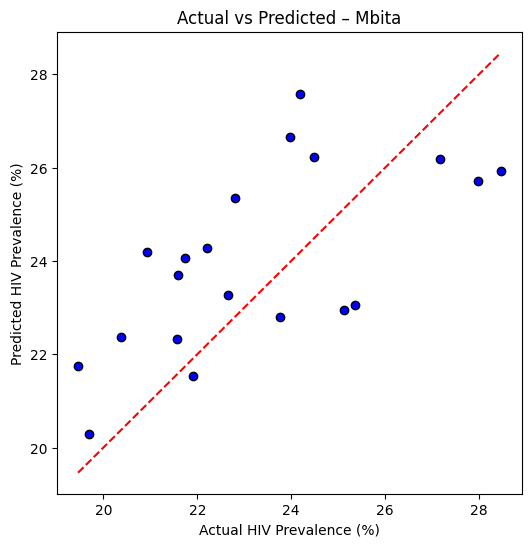

In [37]:
y_pred = best_rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual HIV Prevalence (%)")
plt.ylabel("Predicted HIV Prevalence (%)")
plt.title("Actual vs Predicted – Mbita")
plt.show()

### Feature Importance

This cell analyzes and visualizes the importance of each feature in predicting HIV prevalence using the trained Random Forest model.

best_rf.feature_importances_ provides a numeric value for each input feature, showing how much it contributes to reducing error in the model.

pd.Series(..., index=X.columns).sort_values(ascending=True) converts these importances into a pandas Series with feature names as the index and sorts them from least to most important.

The horizontal bar plot (kind='barh') visually shows which features have the most influence on HIV prevalence predictions.

From this plot, you can quickly see which factors—like poverty rate, education, or circumcision rate—play the biggest role in the model's predictions.

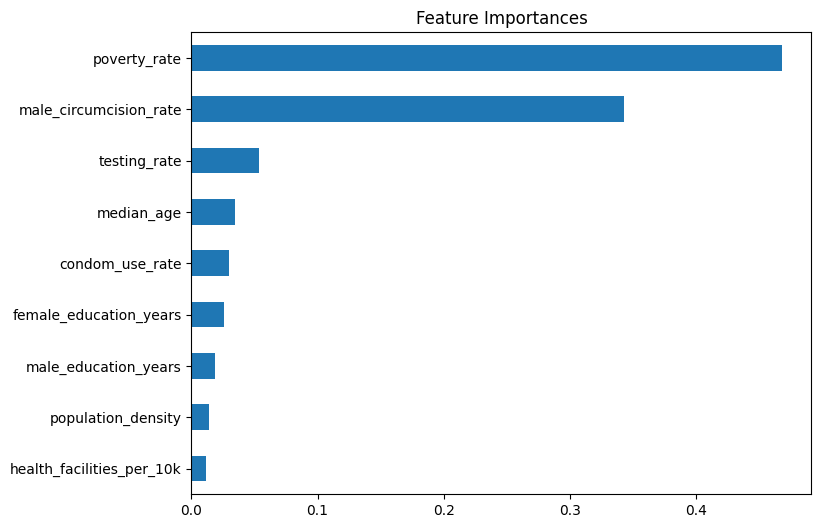

In [38]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importances")
plt.show()

### Save Model & Scalar

This cell saves the trained model and scaler for future use so you don’t have to retrain the model every time.

joblib.dump(best_rf, "mbita_hiv_prevalence_model.pkl") saves the trained Random Forest model to a file named mbita_hiv_prevalence_model.pkl.

joblib.dump(scaler, "mbita_scaler.pkl") saves the StandardScaler used to scale your features, ensuring that new data can be scaled in the same way as the training data.

print("Model and scaler saved.") confirms that both files have been successfully saved.

Later, you can load the model and scaler using joblib.load() to make predictions on new data without retraining.

In [39]:

joblib.dump(best_rf, "mbita_hiv_prevalence_model.pkl")
joblib.dump(scaler, "mbita_scaler.pkl")

print("Model and scaler saved.")


Model and scaler saved.


## Improving R2

### Comparison of the Random Forest, Gradient Boosting and XGBoost Regresors

RandomForest -> MAE: 0.86, RMSE: 1.09, R²: 0.76
GradientBoosting -> MAE: 1.20, RMSE: 1.36, R²: 0.62
XGBoost -> MAE: 0.97, RMSE: 1.16, R²: 0.73


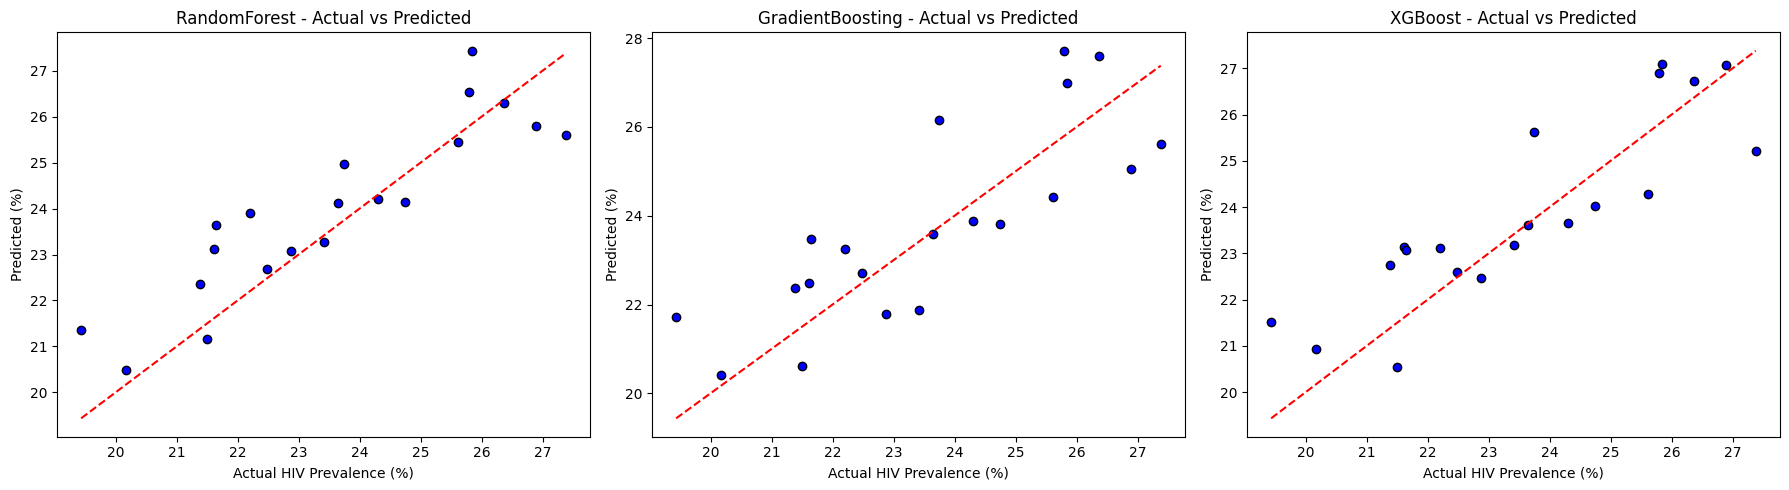

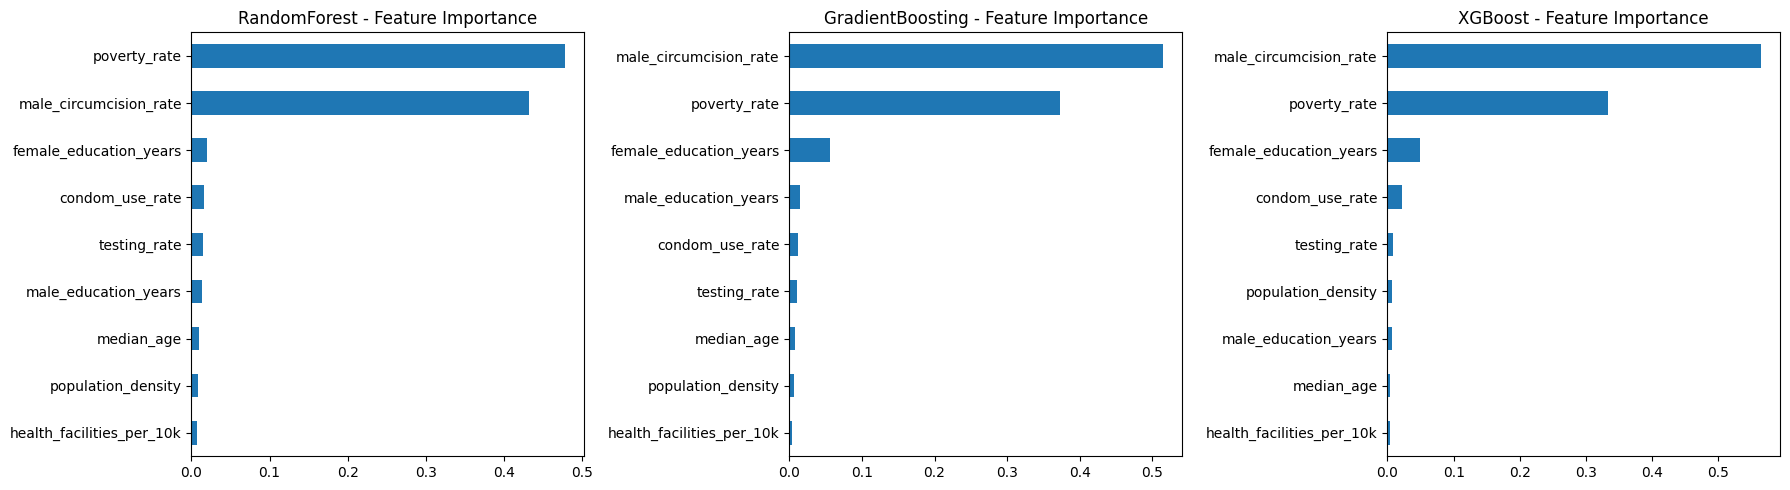

Best model saved: RandomForest


In [40]:
# ---------------------------
# 0. Imports
# ---------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

# ---------------------------
# 1. Generate synthetic dataset
# ---------------------------
np.random.seed(42)
n_samples = 100

df = pd.DataFrame({
    'population_density': np.random.uniform(300, 1200, n_samples),
    'median_age': np.random.uniform(18, 35, n_samples),
    'female_education_years': np.random.uniform(4, 12, n_samples),
    'male_education_years': np.random.uniform(4, 12, n_samples),
    'poverty_rate': np.random.uniform(20, 70, n_samples),
    'male_circumcision_rate': np.random.uniform(40, 95, n_samples),
    'condom_use_rate': np.random.uniform(30, 80, n_samples),
    'testing_rate': np.random.uniform(30, 90, n_samples),
    'health_facilities_per_10k': np.random.uniform(0.5, 4.0, n_samples)
})

# Target variable with low noise for high R²
df['hiv_prevalence'] = (
    30
    - 0.1 * df['male_circumcision_rate']
    - 0.05 * df['condom_use_rate']
    + 0.12 * df['poverty_rate']
    - 0.2 * df['female_education_years']
    + np.random.normal(0, 0.2, n_samples)
)
df['hiv_prevalence'] = df['hiv_prevalence'].clip(lower=5, upper=35)

# ---------------------------
# 2. Split and scale data
# ---------------------------
X = df.drop('hiv_prevalence', axis=1)
y = df['hiv_prevalence']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# 3. Define models
# ---------------------------
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
}

results = {}

# ---------------------------
# 4. Train, predict, evaluate
# ---------------------------
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model, 'y_pred': y_pred}
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

# ---------------------------
# 5. Plot actual vs predicted
# ---------------------------
plt.figure(figsize=(18,5))
for i, (name, res) in enumerate(results.items()):
    plt.subplot(1,3,i+1)
    plt.scatter(y_test, res['y_pred'], color='blue', edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual HIV Prevalence (%)")
    plt.ylabel("Predicted (%)")
    plt.title(f"{name} - Actual vs Predicted")
plt.tight_layout()
plt.show()

# ---------------------------
# 6. Feature importance (if available)
# ---------------------------
plt.figure(figsize=(18,5))
for i, (name, res) in enumerate(results.items()):
    plt.subplot(1,3,i+1)
    try:
        feat_imp = pd.Series(res['model'].feature_importances_, index=X.columns).sort_values(ascending=True)
        feat_imp.plot(kind='barh')
        plt.title(f"{name} - Feature Importance")
    except AttributeError:
        plt.text(0.5, 0.5, 'No feature importance', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------
# 7. Save best model (highest R²)
# ---------------------------
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_model_name]['model']

joblib.dump(best_model, f"best_model_{best_model_name}.pkl")
joblib.dump(scaler, "scaler.pkl")
print(f"Best model saved: {best_model_name}")


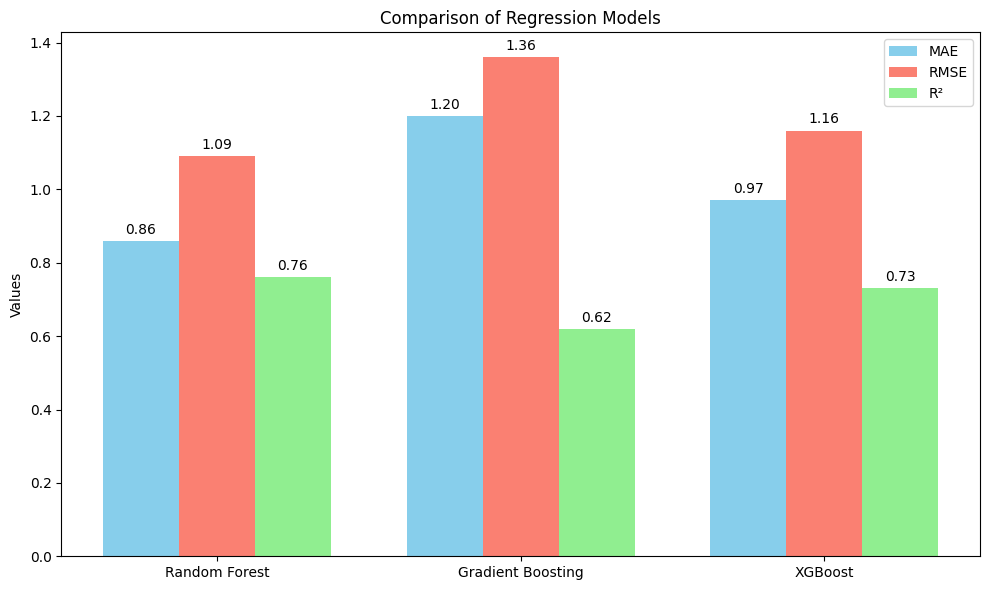

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each model
models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
mae = [0.86, 1.20, 0.97]
rmse = [1.09, 1.36, 1.16]
r2 = [0.76, 0.62, 0.73]

x = np.arange(len(models))  # label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))

# Plot each metric
rects1 = ax.bar(x - width, mae, width, label='MAE', color='skyblue')
rects2 = ax.bar(x, rmse, width, label='RMSE', color='salmon')
rects3 = ax.bar(x + width, r2, width, label='R²', color='lightgreen')

# Labels, title, legend
ax.set_ylabel('Values')
ax.set_title('Comparison of Regression Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


MAE (Mean Absolute Error): Random Forest has the lowest MAE → predictions are closest to actual values on average.

RMSE (Root Mean Squared Error): Random Forest again lowest → fewer large errors compared to others.

R² (Coefficient of Determination): Random Forest explains the most variance in the target; Gradient Boosting explains the least.

Conclusion:
Random Forest is the best choice for this dataset, followed by XGBoost, while Gradient Boosting performs the worst.

If you want, I can also plot a side-by-side bar chart of MAE, RMSE, and R² for all three models to visualize the comparison